Q1

We were asked to write three functions, strict_isom, weak_isom and semi_isom, which take two DFAs and check whether they are strictly, weakly, or semi-isomorphic.

Q2

Each function starts by calling the general function, isom_check, which tries to find bijections satisfying the conditions for the specified isomorphic type and returns a boolean.  

Isom_check first weeds out DFAs which violate the structural conditions for bijections and isomorphisms. It ensures that the DFAs have an equal number of states and letters and that, if searching for a strict isomorphism, the alphabets are equal, before doing any recursion. This avoids unnecessary computation.

Next, Isom_check constructs a mapping f between states from Q1 and Q2 and a mapping g between letters from E1 to E2 depending on the specifications.  For example, the initial state mappings for strict_isom and weak_isom are formed by the start states qs1 and qs2 whereas the start states are ignored in semi-isom. Instead, a helper func, get_source_states, finds the source states of the DFAs and tries to construct a bijection for every combination of source states as the initial mapping.  Using a helper func improves semi_isom’s readability.  For strict_isom, we know that g is the identity func as E1 and E2 are equal.  However, for weak_isom and semi_isom, we must try to build bijections from E1 to any permutation of E2.  

Isom_check does this using the backtracking functions explore_states and explore_letters. Explore_states tries to extend f  to a bijection satisfying the specified conditions. The function recursively explores possible mappings between states by updating the current partial mapping f and checking that the transitions remain constant under the current mappings, backtracking whenever a mapping violates the isomorphic conditions.  It starts by checking that a solution has not already been found. Then explore_states weeds out invalid mappings before recursion by seeing if the number of distinct states reachable from each state is unequal or, for strict_isom and weak_isom, only one state is a start state or an accepting state.  If checking for a weak or semi-isomorphism, explore_states uses explore_letters to construct a suitable bijection between the alphabets of the DFAs while preserving transition consistency with the current state mapping by recursively exploring letter mappings. 

Both backtracking functions check consistency with the helper functions consistent_pair, which checks that a single mapping is consistent, and consistent_transitions, which checks that all transitions remain consistent under the updated state and letter mappings. Separate helper functions such as these and universal functions such as isom_check, explore_states and explore_letters help readability and decrease the amount of repeated code.

Q3

These functions underwent significant changes and improvements. Originally, semi_isom tried to build bijections by trying all possible pairs of starting states using two nested for loops. To increase efficiency, we instead grouped states into strongly connected components, where each state in a group can reach every other state through transitions.  These groups are represented as nodes in a directed graph.  Those with no incoming edges contain the source states of the DFA. Therefore, the improved algorithm only tries pairs of source states as initial mappings. This drastically reduces the search space for semi_isom.

Likewise, explore_states repeatedly searched for unmapped states in Q1 using a for loop and if conditional. However, first assigning the states in a fixed order and then mapping them sequentially decreased scanning and overhead from recursion.  

Initially, a single func consistent_check ensured that only the newest mapping satisfied the conditions. To ensure that all existing pairs stayed consistent whenever a mapping was added, the function, consistent_transitions, which repeatedly used consistent_check  (renamed consistent_pair), was made.  This prevented invalid mappings from propagating deeper into recursion.  Additionally, Consistent_pair initially checked that the mapping satisfied the conditions in the forward direction, that is, the outgoing transitions matched and T1(q,a) and T2(f(q),g(a)).  But adding a reverse check, which checked incoming transitions by looking at all already mapped states and checking that any state that maps into q also maps into f(q), helped detect invalid mappings earlier and reduced the recursion depth.

Q4,5,6

We tested our code on different example DFAs, including edge cases, using functions we wrote which generated random DFAs that were strictly, weakly, semi, and non-isomorphic to a given DFA.  Initial testing gave us the output we expected and additional example DFAs showed that these results were consistent. 
For example, here is the output from strict_isom, weak_isom, and semi_isom on four random DFAs against the DFA given in the project specifications A1.  A2 is strictly isomorphic, A3 is weakly isomorphic, and A4 is semi-isomorphic, and A4 is non-isomorphic to A1. 

[expected output] 

[observed output]

As expected, the functions correctly identify strict, weak, semi-, and non-isomorphisms.

Q7,9

Riannon and I decided to complete the first three isomorphic questions independently and combine our code into one final solution, taking the most efficient parts from either while maintaining readability.  Riannon’s code had stronger backtracking structure, transition validation, and semi-isomorphic checks, while mine had better alphabet mapping and identified structural violations earlier. I combined the solutions. I also found additional ways to opptimize efficenty and revised and rewrote the syntax and comments to create a clear readable format. Meanwhile, Riannon focused on answering the final isomorphic question. 

To help compare our algorithms, we briefly consulted AI, asking it to identify examples where one was more efficient than the other. 

Q8

In [1]:
import networkx as nx
from itertools import permutations
import matplotlib.pyplot as plt

def strict_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are strictly isomorphic i.e. if there is a bijection f: Q1 -> Q2 s.t.
    # T2(f(q), a) = f(T1(q, a)) for all q in Q1 & a in E1
    # f(qs1) = qs2
    # f(F1) = F2
    # The alphabet is the same & unchanged
    # --------------------------------
    return check_isom(A1, A2, "strict")

def weak_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are weakly isomorphic i.e. if there are bijections f: Q1 -> Q2 & g: E1 -> E2 s.t.
    # T2(f(q), g(a)) = f(T1(q, a)) for all q in Q1 & a in E1
    # f(qs1) = qs2
    # f(F1) = F2
    # --------------------------------
    return check_isom(A1, A2, "weak")

def semi_isom(A1, A2):
    # --------------------------------
    # Check whether two DFAs are semi-isomorphic i.e. if there are bijections f: Q1 -> Q2 & g: E1 -> E2 s.t.
    # T2(f(q), g(a)) = f(T1(q, a)) for all q in Q1 & a in E1
    # --------------------------------
    return check_isom(A1, A2, "semi")
       
def check_isom(A1, A2, mode):
    """
    Check whether two DFAs are strictly, weakly, or semi-isomorphic 

    Parameters:
    - A1: 5-tuple forming a DFA
    - A2: 5-tuple forming a DFA
    - mode: String specifying what specific type of isomorphism to check for

    Returns:
    A boolean that equals True if the two DFAs are the specified type of isomorphic & False if they are not
    """
    
    #For each DFA, unpack the 5-tuple & store the states Q, alphabet letters E, transition func T, starting state qs & accepting states F
    Q1, E1, T1, qs1, F1 = A1 
    Q2, E2, T2, qs2, F2 = A2 

    if len(Q1) != len(Q2): #check that A1 & A2 have equal # of states nessesary for a bijection
            return False
    if mode == "strict" and E1 != E2: #if checking for strict isom, check that alphabets E1 & E2 are equal
            return False
    elif len(E1) != len(E2): #if checking for weak or semi isom, check that alphabets E1 & E2 are equal size
            return False

    def get_source_states(A):
        """
        Find the source states of a DFAs transition graph

        Parameters:
        - A: 5-tuple forming a DFA

        Returns:
        A list containing the source states of a DFAs transition graph
        """
        #unpack the 5-tuple forming A 
        Q, E, T, qs, F = A

        #create directed graph to show transitions structure of DFA
        G = nx.DiGraph()
        G.add_nodes_from(Q)
        for (q, a), r in T.items():
            G.add_edge(q,r)

        #sort states into groups where every state can reach every other state by following transitions & store in directed graph as nodes
        C = nx.condensation(G)

        #create list to store source states belonging to these groups
        sources = []
        #for each group
        for node in C.nodes:
            if C.in_degree(node) == 0: #if there are no groups that transition into this group
                sources.extend(C.nodes[node]['members']) #add these to the list of source states

        return sources 

    def explore_states(f, g, seen_states, seen_letters):
        """
        Try to construct a suitable bijection between states of the DFAs
        Recursively explore possible mappings between states by updating the current partial bijection f and checking that transitions remain consistent,
        backtracking whenever a mapping violates the isomorphism conditions

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - seen_states: A set of states in Q2 that have already been mapped to by f 
        - seen_letters: A set of letters in E2 that have already been mapped to by g 

        Returns:
        A boolean that equals True if bijections between states & between alphabets satisfying the isomorphic conditons are found & False if not
        """

        if len(f) == len(Q1): #check if state mapping f is a complete bijection
            return True

        #for each unmapped state q in Q1
        for q in Q1:
            if q not in f:
                break

        #try mapping q to every unseen state in Q2
        for s in Q2:
            if s in seen_states:
                continue

            if len({T1[(q,a)] for a in E1}) != len({T2[(s,b)] for b in E2}): #check that # of distinct states reachable from q & s are equal
                continue #this reduces the # of mappings explored by removing those that cannot form a bijection 
                
            if mode != "semi": #if checking for strict or weak isom
                
                if (q in F1) != (s in F2): #check that states q & s are both accepting or both not accepting
                    continue #this reduces the # of mappings explored by removing those that fail the conditions  
                
                if q == qs1 and s != qs2: #check that states q & s are both starting states or both not starting
                    continue

            f[q] = s #temporarily map q to state s via f 
            seen_states.add(s) #& add s to seen states

            if mode == "strict": #if checking for strict isom
    
                if consistent_transitions(f,g): #consistency check the updated state mapping f
                    if explore_states(f, g, seen_states, seen_letters): #then try mapping remaining states in Q1
                        return True
            
            else: #if checking for weak or semi isom
                
                if explore_letters(f, g, q, s, seen_letters): #try mapping the letters corresponding to these states & consistency check the updated state & letter mappings f & g
                    if explore_states(f, g, seen_states, seen_letters): #then try mapping remaining states in Q1 
                        return True 

            #if the updated state & letter mappings f & g are inconsistent, backtrack & try the next unseen state in Q2
            del f[q]
            seen_states.remove(s)
        
        return False

    
    def explore_letters(f, g, q, s, seen_letters):
        """
        Try to construct a suitable bijection between the alphabets of the DFAs 
        while preserving transition concistency with the current state mapping by recursively exploring letter mappings

        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - q: A state in Q1
        - s: A state in Q2
        - seen_letters: A set of letters in E2 that have already been mapped to by g

        Returns:
        A boolean that equals True if a bijection satisfying these conditions is found & False if not
        """

        #for each letter a in E1
        for a in E1:
            if a in g: #if g already maps a to a letter in E2
                b = g[a]
                
                if not consistent_pair(f, g, q, s, a, b): #consistency check the mapped pair under the current state mapping f & letter mapping g
                    return False
                    
            else: #if a is not already mapped to a letter in E2 
                
                #try mapping a to every unseen letter b in E2
                for b in E2:
                    if b in seen_letters:
                        continue

                    g[a] = b #temporarily map a to letter b in E2 via g 
                    seen_letters.add(b) #& add b to seen letters

                    if consistent_pair(f, g, q, s, a, b): #consistency check the mapped pair under the current state mapping f & letter mapping g
                        if explore_letters(f, g, q, s, seen_letters): #then try mapping the remaining letters in E1
                            return True

                    #if the updated state & letter mappings f & g are inconsistent, backtrack & try the next unseen letter in E2
                    del g[a]
                    seen_letters.remove(b)
                return False
        return True

    def consistent_pair(f, g, q, s, a, b):
        """
        Given a mapped pair, check that their single transition mapping is consistent with the current state mapping f & letter mapping g
        
        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters
        - q: A state in Q1
        - s: A state in Q2 mapped to q via f
        - a: A letter in E1
        - b: A letter in E2 mapped to a via g

        Returns:
        A boolean that equals True if the single transition is consistent & False if not
        """
    
        #find & store T1(q,a) & T2(f(q),g(a)) 
        t1 = T1[(q,a)]
        t2 = T2[(s,b)]
    
        #check that f(T1(q,a)) is not already mapped to a state other than T2(f(q),g(a)) 
        #forward check
        if t1 in f and f[t1] != t2: 
            return False
        #reverse check
        for q2, s2 in f.items():
            if T1.get((q2,a)) == q and T2.get((s2, b)) != s:
                return False
        return True

    def consistent_transitions(f, g):
        """
        Check that all transitions remain consistent under the updated state & letter mappings f & g
        
        Parameters:
        - f: A partial bijection between states
        - g: A partial bijection between letters

        Returns:
        A boolean that equals True if the transitions are consistent & False if not
        """
        #for each pair of mapped state & letter
        for q in f:
            
            for a in E1:
                if a not in g:
                    continue
                b = g[a]
                if not consistent_pair(f, g, q, f[q], a, b): #& check that their transition is consistent with the current state mapping f & letter mapping g
                    return False
        return True
    
    if mode == "strict": #if checking for strict
        
        f = {qs1 : qs2} #create bijection f with initial mapping from qs1 to qs2
        seen_states = {qs2} #create set to keep track of states in Q2 that have already been mapped to by f & add qs2

        g = {a: a for a in E1} #create bijection g for mapping letters from E1 to E2
        seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

        #try finding bijections f & g that satisfy the conditions given the DFA
        return explore_states(f, g, seen_states, seen_letters)
    
    elif mode == "weak": #if checking for weak

        #sort the alphabets to later index
        letters1 = sorted(E1)
        letters2 = sorted(E2)

        #for every possible bijection g mapping letters from E1 to E2
        for perm in permutations(letters2):
            
            f = {qs1 : qs2} #create bijection f with initial mapping from qs1 to qs2
            seen_states = {qs2} #create set to keep track of states in Q2 that have already been mapped to by f & add qs2

            g = {letters1[i]: perm[i] for i in range(len(letters1))} #store the bijection g by indexing the uniquely ordered letters in E2
            seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

            #try finding bijections f & g that satisfy the conditions given the DFA
            if explore_states(f, g, seen_states, seen_letters):
                return True
        return False
    
    elif mode == "semi":
        #find the source states of A1 & A2
        sources1 = get_source_states(A1)
        sources2 = get_source_states(A2)

        #sort the alphabets to later index
        letters1 = sorted(E1)
        letters2 = sorted(E2)

        #for every possible bijection g mapping letters from E1 to E2
        for perm in permutations(letters2):

            g = {letters1[i]: perm[i] for i in range(len(letters1))} #store the bijection g by indexing the uniquely ordered letters in E2

            #then for each pair of source states q & s
            for q in sources1:
                for s in sources2:

                    f = {q:s} #create bijection f with initial mapping from q to s
                    seen_states = {s} #create set to keep track of states in Q2 that have already been mapped to by f & add s

                    seen_letters = set() #create set to keep track of letters in E2 that have already been mapped to by g

                    #try finding bijections f & g that satisfy the conditions given the DFA
                    if explore_states(f, g, seen_states, seen_letters):
                        return True
    return False

Check two strictly isom DFAs:
True
True
True
Check two weakly isom DFAs:
False
True
True
Check two semi-isom DFAs:
False
False
True


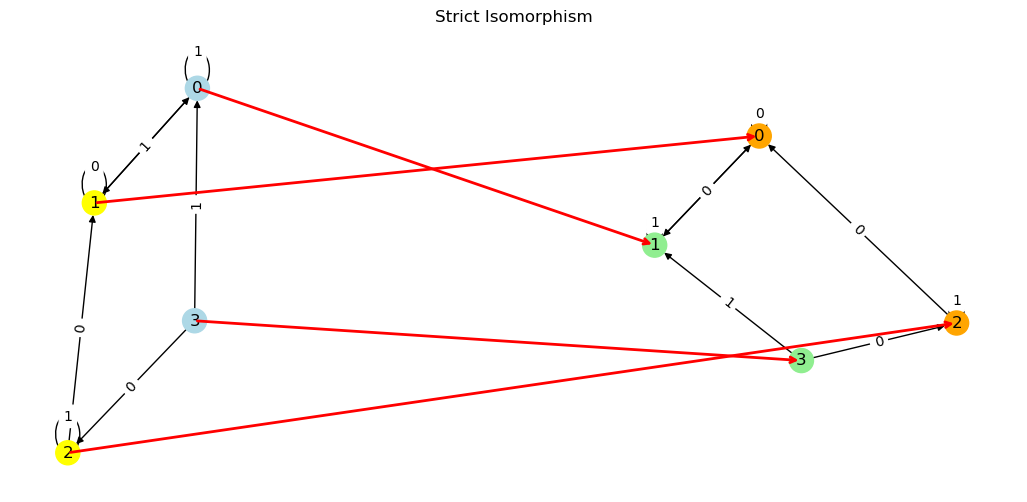

None


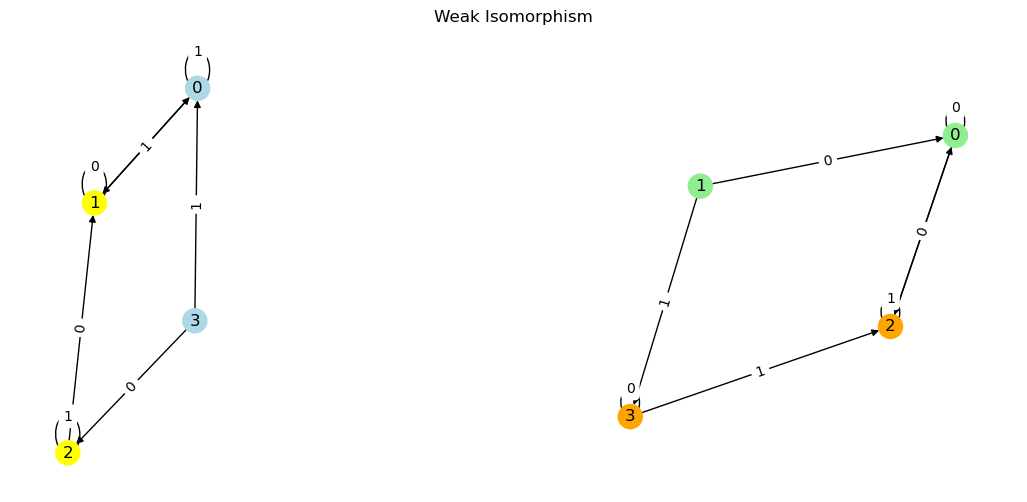

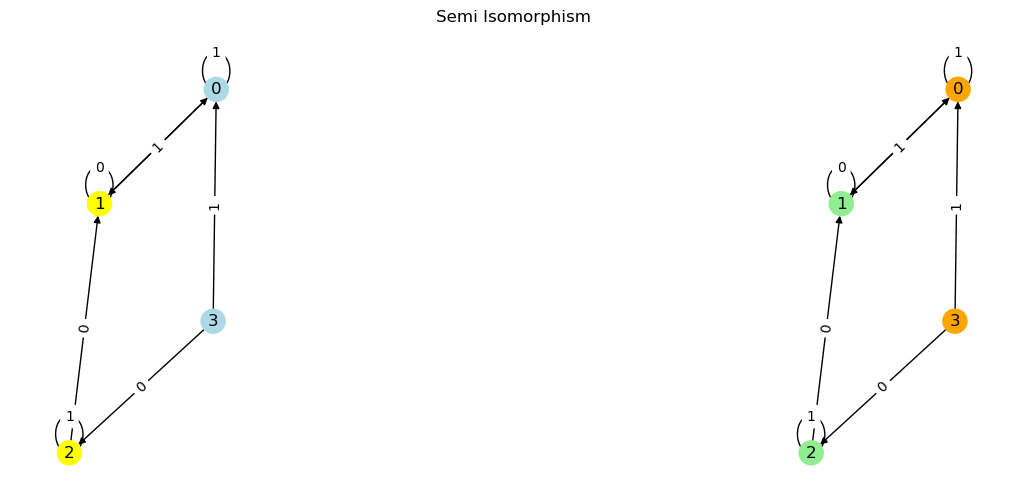

In [33]:
#TESTING
import random
from itertools import permutations, product
#use example DFA from project background
# states {0,1,2,3}, alphabet {0,1}, start state 3, accepting {1,2}
A1 = (
    {0, 1, 2, 3},
    {0, 1},
    {(0,0):1, (0,1):0, (1,0):1, (1,1):0, (2,0):1, (2,1):2, (3,0):2, (3,1):0},
    3,
    {1, 2}
)

def random_strict_isom(A1):
    """
    Create a random DFA, A2, s.t. it is strictly isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 to a list
    states = list(Q1)
    #create a copy of the list
    perm = states[:]
    #randomly shuffle this copy
    random.shuffle(perm)

    #create a bijection f mapping states in Q1 to shuffled states
    f = {states[i]: perm[i] for i in range(len(states))}

    #create new transition func, start states, and accepting states using f
    T2 = {(f[q], a): f[r] for (q,a), r in T1.items()}
    qs2 = f[qs1]
    F2 = {f[q] for q in F1}

    return (set(perm), E1, T2, qs2, F2)

def random_weak_isom(A1):
    """
    Create a random DFA, A2, s.t. it is weakly isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 & letters in E1 to lists
    states = list(Q1)
    letters = list(E1)

    #create copies of these lists
    state_perm = states[:]
    letter_perm = letters[:]

    #randomly shuffle these copies
    random.shuffle(state_perm) 
    while True: #while shuffling the letters, check that g is not the identity func
        random.shuffle(letter_perm)
        if any(letters[i] != letter_perm[i] for i in range(len(letters))):
            break
    
    #create a bijection f mapping states in Q1 to shuffled states
    f = {states[i]: state_perm[i] for i in range(len(states))}   
    #create a bijection g mapping letters in E1 to shuffled letters
    g = {letters[i]: letter_perm[i] for i in range(len(letters))}

    #create new transition func, start states, & accepting states using f & g
    T2 = {(f[q], g[a]): f[r] for (q,a), r in T1.items()}
    qs2 = f[qs1]
    F2 = {f[q] for q in F1}

    return (set(state_perm), set(letter_perm), T2, qs2, F2)

def random_semi_isom(A1):
    """
    Create a random DFA, A2, s.t. it is semi-isomorphic to the given DFA

    Parameters:
    - A1: 5-tuple forming a DFA

    Returns:
    A 5-tuple forming a DFA
    """
    #unpack DFA
    Q1, E1, T1, qs1, F1 = A1

    #convert states in Q1 to a list
    states = list(Q1)

    while True:
        #randomly chose a start state
        qs2 = random.choice(states)
        #randomly sample accepting states from Q1 & store as F2
        n = random.randint(0, len(states))
        F2 = set(random.sample(states, n))
        if qs1 != qs2 or F1 != F2: #check that these never satisfy the conditions for strictly or weakly isom
            break

    return (Q1, E1, T1, qs2, F2)

print("Check two strictly isom DFAs:")
print(strict_isom(A1, random_strict_isom(A1)))
print(weak_isom(A1, random_strict_isom(A1)))
print(semi_isom(A1, random_strict_isom(A1)))

print("Check two weakly isom DFAs:")
print(strict_isom(A1, random_weak_isom(A1)))
print(weak_isom(A1, random_weak_isom(A1)))
print(semi_isom(A1, random_weak_isom(A1)))

print("Check two semi-isom DFAs:")
print(strict_isom(A1, random_semi_isom(A1)))
print(weak_isom(A1, random_semi_isom(A1)))
print(semi_isom(A1, random_semi_isom(A1)))


A1 = (
    {0, 1, 2, 3},
    {0, 1},
    {(0,0):1, (0,1):0, (1,0):1, (1,1):0, (2,0):1, (2,1):2, (3,0):2, (3,1):0},
    3,
    {1, 2}
)
def unpack_dfa(A): # seperates the parts of the DFA
    Q, Sigma, delta, q0, F = A
    return Q, Sigma, delta, q0, F


def build_graph(A1):
    Q, Sigma, delta, q0, F = unpack_dfa(A1) # Unpacks parts of DFA
    G=nx.DiGraph()
    for q in Q:
        G.add_node(q,accepting=(q in F),start=(q==q0)) # adds all points in DFA to the graph
    for (state,sym), target in delta.items():
        G.add_edge(state,target,label=str(sym)) # Shows direction of points connections to one another
    return G
def draw_dfas(A,B,mapping=None, Title="DFA comparison"):
    
    GA=build_graph(A)
    GB=build_graph(B)

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.set_title(Title)

    posA = nx.spring_layout(GA, seed=1)
    for k in posA:
        posA[k] = (posA[k][0] - 2, posA[k][1])

    posB = nx.spring_layout(GB, seed=1)
    for k in posB:
        posB[k] = (posB[k][0] + 2, posB[k][1])
    
    node_colors_A = ["lightblue" if not GA.nodes[n]["accepting"] else "yellow" for n in GA.nodes]
    nx.draw(GA, posA, with_labels=True, node_color=node_colors_A, edge_color="black", ax=ax)
    nx.draw_networkx_edge_labels(GA, posA, edge_labels=nx.get_edge_attributes(GA, "label"), ax=ax)

    # draw DFA B (right)
    node_colors_B = ["lightgreen" if not GB.nodes[n]["accepting"] else "orange" for n in GB.nodes]
    nx.draw(GB, posB, with_labels=True, node_color=node_colors_B, edge_color="black", ax=ax)
    nx.draw_networkx_edge_labels(GB, posB, edge_labels=nx.get_edge_attributes(GB, "label"), ax=ax)

    # draw mapping arrows between DFAs
    if mapping:
        for qa, qb in mapping.items():
            x1, y1 = posA[qa]
            x2, y2 = posB[qb]
            ax.annotate(
                "",
                xy=(x2, y2),
                xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", color="red", lw=2)
            )

    plt.axis("off")
    plt.show() # Shows the graphs

def reachable_states(Q, delta, q0, Sigma):
    visited = set()
    stack = [q0]
    while stack:
        s = stack.pop()
        if s not in visited:
            visited.add(s)
            for a in Sigma:
                stack.append(delta[(s, a)])
    return visited


def find_iso_mapping(A,B,mode="strict"):
    QA, SigmaA, deltaA, q0A, FA = unpack_dfa(A) # unpacks DFA's tp be easily used
    QB, SigmaB, deltaB, q0B, FB = unpack_dfa(B)
    
    if SigmaA != SigmaB:
        return None
        
    if mode == "strict":
        if len(QA) != len(QB) or len(FA) != len(FB):
            return None
        statesA = sorted(QA)
        statesB = sorted(QB)

    elif mode == "weak":
        # only compare reachable parts
        RA = reachable_states(QA, deltaA, q0A, SigmaA)
        RB = reachable_states(QB, deltaB, q0B, SigmaB)

        if len(RA) != len(RB):
            return None

        statesA = sorted(RA)
        statesB = sorted(RB)

        FA = FA & RA
        FB = FB & RB
    elif mode == "semi":
        # allow collapsing A into subset of B
        if len(QA) < len(QB):
            return None  # A must be greater than B for merging

        statesA = sorted(QA)
        statesB = sorted(QB)

    if mode in ["strict", "weak"]:
        permutation = permutations(statesB)
    else:  # semi
        permutation = product(statesB, repeat=len(statesA))
    for perm in permutation:
        mapping = dict(zip(statesA, perm)) # This collects all state information of A and corresponding permuted point from B

        # start state preserved
        if mapping[q0A] != q0B: # while the initial point does not map to the other DFA's inital point we continue
           continue

        # accepting states preserved
        if mode != "semi":
            if {mapping[q] for q in FA} != FB:
                continue
        else:
            # semi: accepting states map INTO FB (not exact match)
            if not all(mapping[q] in FB for q in FA):
                continue

        OK = True # while this is true we return a mapping at the end
        for (s, sym), targetA in deltaA.items(): #for each tuple and point in the 1st DFA
            if s not in mapping or targetA not in mapping:
                continue
                
            mapped_s  = mapping[s]
            if (mapped_s, sym) not in deltaB:
                OK = False
                break
            targetB   = deltaB[(mapped_s, sym)]
    
            if mapping[targetA] != targetB: # makes sure the mapped point is within the second DFA if it isnt stops mapping 
                OK = False
                break
        #as long as no issues have been found gives the mapping
        if OK:
            return mapping
    return None
#This defines the two DFA's which fullfill each requirements
A=A1
B=random_strict_isom(A1)

C=random_weak_isom(A1)

D=random_semi_isom(A1)

strict_iso=strict_isom(A,B)
weak_iso=weak_isom(A,C)

semi_iso=semi_isom(A,D)




#Below checks if each is true or false and if true draws mappings between and otherwise just draws the two DFA's
if strict_iso==True:
    mapping = find_iso_mapping(A,B)
    draw_dfas(A, B, mapping, "Strict Isomorphism")
else:
    draw_dfas(A, B, None, "NOT Strict Isomorphic")

if weak_iso==True:
    mapping = find_iso_mapping(A, C,"weak")
    print(mapping)
    draw_dfas(A, C, mapping, "Weak Isomorphism")
else:
    draw_dfas(A, C, None, "NOT Weakly Isomorphic")
if semi_iso==True:
    mapping = find_iso_mapping(A, D,"semi")
    draw_dfas(A, D, mapping, "Semi Isomorphism")
else:
    draw_dfas(A, D, None, "NOT Semi-Isomorphic")